In [ ]:

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

CONFIG = {
    'tickers': ['AAPL', 'MSFT', 'NVDA', 'AMZN', 'GOOGL', 'META', 'TSLA', 'JPM', 'JNJ', 'KO'],
    'data_dir': '../data',  # Relative path from src/backend/models/train/
    'seq_len': 60,          # Lookback window
    'pred_horizon': 5,      # Predict 5-day cumulative return
    'hidden_size': 32,
    'layers': 1,
    'dropout': 0.2,
    'batch_size': 64,
    'learning_rate': 0.001,
    'epochs': 20,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

torch.manual_seed(42)
np.random.seed(42)

# Check that data path exists
data_path = Path(CONFIG['data_dir']).resolve()
print(f"Running on {CONFIG['device']}")
print(f"Data Directory resolved to: {data_path}")
if not data_path.exists():
    print("WARNING: Data directory does not exist! Check your path.")

Running on cpu
Data Directory resolved to: /Users/macbook/Downloads/HCMUT/Assignments/AI Projects/trend-spy-bot/src/backend/models/data


In [ ]:
def load_local_data(tickers, data_dir):
    print(f"Loading {len(tickers)} tickers from local storage...")
    data = {}
    path = Path(data_dir)
    
    for ticker in tickers:
        file_path = path / f"{ticker}.csv"
        
        if file_path.exists():
            try:
                df = pd.read_csv(file_path)
                df.columns = df.columns.str.strip().str.title()
                if 'Date' in df.columns:
                    df['Date'] = pd.to_datetime(df['Date'])
                    # Crucial: sort by date for time series operations
                    df = df.sort_values('Date').set_index('Date')
                
                required_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
                if all(col in df.columns for col in required_cols):
                    data[ticker] = df
                    print(f"  {ticker}: {len(df)} rows loaded")
                else:
                    print(f"{ticker}: Missing required columns. Found: {df.columns.tolist()}")
                    
            except Exception as e:
                print(f"Error reading {ticker}: {e}")
        else:
            print(f"File not found: {file_path}")
            
    return data

raw_data = load_local_data(CONFIG['tickers'], CONFIG['data_dir'])

if len(raw_data) == 0:
    raise ValueError("No data loaded. Please check your data directory and file names.")

Loading 10 tickers from local storage...
  AAPL: 11332 rows loaded
  MSFT: 10006 rows loaded
  NVDA: 6755 rows loaded
  AMZN: 7180 rows loaded
  GOOGL: 5354 rows loaded
  META: 3402 rows loaded
  TSLA: 3879 rows loaded
  JPM: 10561 rows loaded
  JNJ: 14098 rows loaded
  KO: 14098 rows loaded


In [ ]:
def engineer_features(df):
    df = df.copy()
    
    df['Log_Ret'] = np.log(df['Close'] / df['Close'].shift(1)) * 100
    
    # Crucial: Predict sum of next 5 days
    df['Target_5D'] = df['Log_Ret'].rolling(window=5).sum().shift(-5)

    for p in [5, 10, 20]:
        df[f'ROC_{p}'] = df['Close'].pct_change(p) * 100

    df['Vol_20'] = df['Log_Ret'].rolling(20).std()
    
    df['Vol_Ratio'] = df['Volume'] / df['Volume'].rolling(20).mean()
    
    delta = df['Close'].diff()
    gain = (delta.where(delta > 0, 0)).ewm(span=14, adjust=False).mean()
    loss = (-delta.where(delta < 0, 0)).ewm(span=14, adjust=False).mean()
    rs = gain / loss.replace(0, 1e-9)
    df['RSI'] = 100 - (100 / (1 + rs))
    
    df['RSI'] = df['RSI'] / 100.0
    
    return df.dropna()

processed_data = {}
for ticker, df in raw_data.items():
    processed_data[ticker] = engineer_features(df)
    
print(f"Processed {len(processed_data)} tickers. Example features:\n")
print(processed_data['AAPL'][['Log_Ret', 'Target_5D', 'RSI', 'Vol_20']].head())

Processed 10 tickers. Example features:

             Log_Ret  Target_5D       RSI    Vol_20
Date                                               
1981-01-13 -3.621891   4.409247  0.413465  4.504795
1981-01-14  0.408972   5.941962  0.424563  4.303963
1981-01-15  2.020146   5.068985  0.481196  3.852667
1981-01-16 -0.803172   5.491221  0.460288  3.859932
1981-01-19  5.872158  -1.919333  0.607770  3.996678


In [ ]:
train_dfs = []
test_dfs = []

# Split Date
split_date = '2020-01-01'
resume_date = '2021-01-01'

for ticker, df in processed_data.items():
    train = df[df.index < split_date].copy()
    test = df[df.index >= resume_date].copy()
    
    train['Ticker'] = ticker
    test['Ticker'] = ticker
    
    train_dfs.append(train)
    test_dfs.append(test)

# Combine for Scaling
full_train = pd.concat(train_dfs)
full_test = pd.concat(test_dfs)

# Exclude target, id columns, raw price columns
feature_cols = [c for c in full_train.columns if c not in ['Target_5D', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Volume', 'Adj Close']]
print(f"Features ({len(feature_cols)}): {feature_cols}")

# Fit scaler using only TRAIN data to avoid leakage
scaler = StandardScaler()
full_train[feature_cols] = scaler.fit_transform(full_train[feature_cols])
full_test[feature_cols] = scaler.transform(full_test[feature_cols])

print(f"Train Rows: {len(full_train)}, Test Rows: {len(full_test)}")

Features (7): ['Log_Ret', 'ROC_5', 'ROC_10', 'ROC_20', 'Vol_20', 'Vol_Ratio', 'RSI']
Train Rows: 71615, Test Rows: 12270


In [ ]:
class BaselineDataset(Dataset):
    def __init__(self, df, seq_len, features, target_col='Target_5D'):
        self.data = df
        self.seq_len = seq_len
        self.features = features
        self.target_col = target_col
        
        # Keep windows confined within each ticker
        self.sequences = []
        for ticker in df['Ticker'].unique():
            ticker_df = df[df['Ticker'] == ticker]
            data_values = ticker_df[features].values
            target_values = ticker_df[target_col].values
            
            for i in range(len(ticker_df) - seq_len):
                x = data_values[i : i+seq_len]
                y = target_values[i+seq_len-1] # target aligns at end of sequence
                self.sequences.append((x, y))
                
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        x, y = self.sequences[idx]
        return torch.FloatTensor(x), torch.FloatTensor([y])

train_ds = BaselineDataset(full_train, CONFIG['seq_len'], feature_cols)
test_ds = BaselineDataset(full_test, CONFIG['seq_len'], feature_cols)

train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True)
test_loader = DataLoader(test_ds, batch_size=CONFIG['batch_size'], shuffle=False)

print(f"Train Batches: {len(train_loader)}")

Train Batches: 1110


In [ ]:
class ProbabilisticLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, dropout):
        super(ProbabilisticLSTM, self).__init__()
        self.lstm = nn.LSTM(
            input_dim, 
            hidden_dim, 
            num_layers, 
            batch_first=True, 
            dropout=dropout
        )
        self.head = nn.Linear(hidden_dim, 2)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        last_step = out[:, -1, :]
        outputs = self.head(last_step)
        mu = outputs[:, 0]      # Predicted Mean
        log_var = outputs[:, 1] # Predicted Log Variance
        return mu, log_var

In [ ]:
class GaussianNLLLoss(nn.Module):
    def __init__(self, eps=1e-6):
        super(GaussianNLLLoss, self).__init__()
        self.eps = eps

    def forward(self, mu, log_var, target):
        # Ensure target shape matches mu
        target = target.view_as(mu)
        
        # Clamp log_var to prevent explosion/underflow during exp()
        # Range -10 to 10 covers variance from ~0.00004 to ~22000
        log_var = torch.clamp(log_var, min=-10, max=10) 
        var = torch.exp(log_var)
        
        # GNLL: 0.5 * (log(var) + (target - mu)^2 / var)
        loss = 0.5 * (log_var + (target - mu)**2 / (var + self.eps))
        
        return loss.mean()

In [ ]:
model = ProbabilisticLSTM(
    len(feature_cols), 
    CONFIG['hidden_size'], 
    CONFIG['layers'], 
    CONFIG['dropout']
).to(CONFIG['device'])

optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG['learning_rate'])
criterion = GaussianNLLLoss() # Replaces MSELoss

def train_step(loader):
    model.train()
    total_loss = 0
    
    for x, y in loader:
        x, y = x.to(CONFIG['device']), y.to(CONFIG['device'])
        optimizer.zero_grad()
        mu, log_var = model(x)
        loss = criterion(mu, log_var, y)
        loss.backward()
        # Gradient clipping prevents exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
        
    return total_loss / len(loader)

def evaluate(loader):
    model.eval()
    preds_mu = []
    preds_sigma = []
    actuals = []
    
    with torch.no_grad():
        for x, y in loader:
            x = x.to(CONFIG['device'])
            mu, log_var = model(x)
            # Convert log_var to standard deviation (sigma) for analysis
            sigma = torch.exp(0.5 * log_var)
            preds_mu.extend(mu.cpu().numpy())
            preds_sigma.extend(sigma.cpu().numpy())
            actuals.extend(y.numpy())
            
    return np.array(preds_mu), np.array(preds_sigma), np.array(actuals)

/Users/macbook/.pyenv/versions/3.11.7/lib/python3.11/site-packages/torch/nn/modules/rnn.py:83: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "
/Users/macbook/.pyenv/versions/3.11.7/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Starting Phase 2 Training (Probabilistic) on cpu...
Epoch 1 | Train GNLL: 2.4476 | Test GNLL: 1.9255
Epoch 2 | Train GNLL: 1.9463 | Test GNLL: 1.9188
Epoch 3 | Train GNLL: 1.9429 | Test GNLL: 1.9223
Epoch 4 | Train GNLL: 1.9393 | Test GNLL: 1.9174
Epoch 5 | Train GNLL: 1.9358 | Test GNLL: 1.9185
Epoch 6 | Train GNLL: 1.9347 | Test GNLL: 1.9202
Epoch 7 | Train GNLL: 1.9315 | Test GNLL: 1.9256
Epoch 8 | Train GNLL: 1.9284 | Test GNLL: 1.9229
Epoch 9 | Train GNLL: 1.9270 | Test GNLL: 1.9232
Epoch 10 | Train GNLL: 1.9258 | Test GNLL: 1.9275
Epoch 11 | Train GNLL: 1.9243 | Test GNLL: 1.9256
Epoch 12 | Train GNLL: 1.9220 | Test GNLL: 1.9260
Epoch 13 | Train GNLL: 1.9190 | Test GNLL: 1.9268
Epoch 14 | Train GNLL: 1.9175 | Test GNLL: 1.9259
Epoch 15 | Train GNLL: 1.9159 | Test GNLL: 1.9213
Epoch 16 | Train GNLL: 1.9135 | Test GNLL: 1.9317
Epoch 17 | Train GNLL: 1.9111 | Test GNLL: 1.9249
Epoch 18 | Train GNLL: 1.9099 | Test GNLL: 1.9244
Epoch 19 | Train GNLL: 1.9063 | Test GNLL: 1.9295
Epoch 2

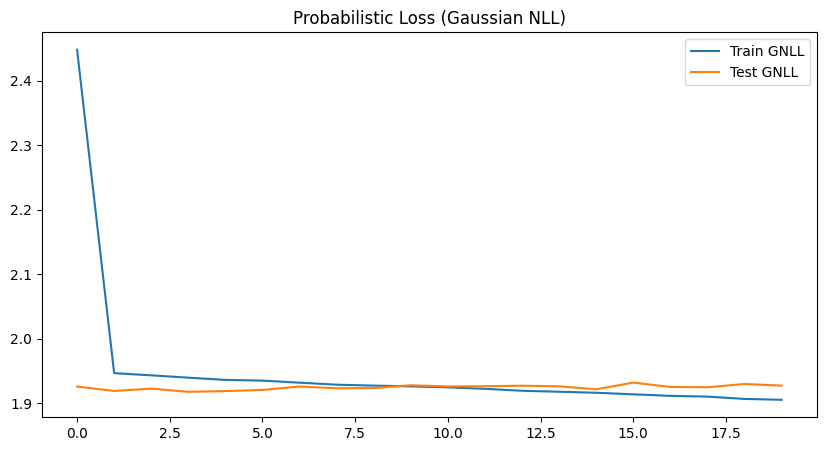

In [ ]:
history = {'train_loss': [], 'test_gnll': []}

print(f"Starting Phase 2 Training (Probabilistic) on {CONFIG['device']}...")

for epoch in range(CONFIG['epochs']):
    train_loss = train_step(train_loader)
    
    # Evaluate (Calculate GNLL on Test Set)
    model.eval()
    test_loss = 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(CONFIG['device']), y.to(CONFIG['device'])
            mu, log_var = model(x)
            loss = criterion(mu, log_var, y)
            test_loss += loss.item()
    test_loss /= len(test_loader)
    
    history['train_loss'].append(train_loss)
    history['test_gnll'].append(test_loss)
    
    print(f"Epoch {epoch+1} | Train GNLL: {train_loss:.4f} | Test GNLL: {test_loss:.4f}")

# Plot Loss
plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='Train GNLL')
plt.plot(history['test_gnll'], label='Test GNLL')
plt.title("Probabilistic Loss (Gaussian NLL)")
plt.legend()
plt.show()

--- Phase 2 Results (Probabilistic) ---
MAE: 3.4947
IC (Spearman): 0.0108
Directional Acc: 52.96%
Sigma-Error Correlation: 0.4023 (Should be Positive)


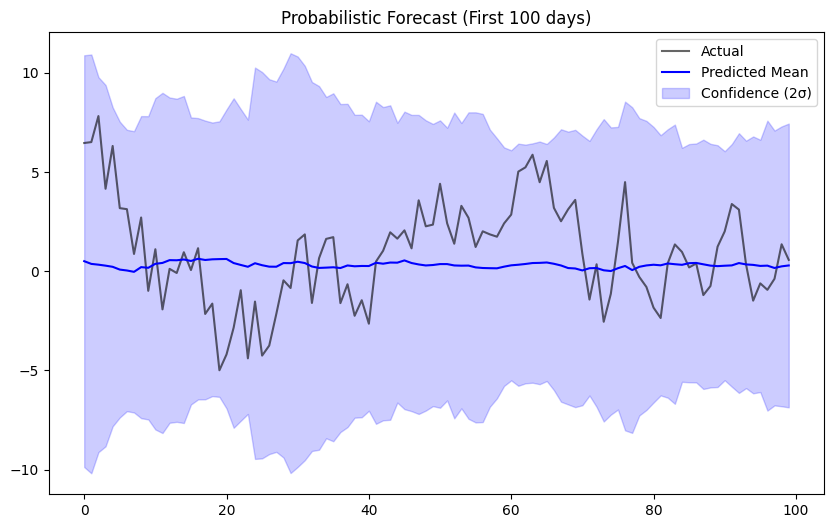

In [ ]:

# Run inference
preds_mu, preds_sigma, actuals = evaluate(test_loader)

# Flatten dimensions to prevent broadcasting errors
preds_mu = preds_mu.flatten()
preds_sigma = preds_sigma.flatten()
actuals = actuals.flatten()

# Calculate Metrics
mae = np.mean(np.abs(preds_mu - actuals))
ic, p_val = spearmanr(preds_mu, actuals)
direction_acc = np.mean((preds_mu > 0) == (actuals > 0))

print(f"--- Phase 2 Results (Probabilistic) ---")
print(f"MAE: {mae:.4f}")
print(f"IC (Spearman): {ic:.4f}")
print(f"Directional Acc: {direction_acc*100:.2f}%")

# Uncertainty Analysis
errors = np.abs(preds_mu - actuals)

# Correlation between predicted uncertainty and actual error
sigma_corr, _ = spearmanr(preds_sigma, errors)
print(f"Sigma-Error Correlation: {sigma_corr:.4f} (Should be Positive)")

# Visualization
plt.figure(figsize=(10, 6))
subset = 100
x_range = range(subset)

plt.plot(x_range, actuals[:subset], label='Actual', color='black', alpha=0.6)
plt.plot(x_range, preds_mu[:subset], label='Predicted Mean', color='blue')

# Plot 2-Sigma Bounds (95% Confidence)
lower = preds_mu[:subset] - 2 * preds_sigma[:subset]
upper = preds_mu[:subset] + 2 * preds_sigma[:subset]
plt.fill_between(x_range, lower, upper, color='blue', alpha=0.2, label='Confidence (2σ)')

plt.title(f"Probabilistic Forecast (First {subset} days)")
plt.legend()
plt.show()

In [ ]:
from scipy.stats import norm
import numpy as np

# Coverage: percentage of actuals within ±1σ
lower = preds_mu - preds_sigma
upper = preds_mu + preds_sigma
coverage = np.mean((actuals >= lower) & (actuals <= upper)) * 100
print(f"1σ Coverage: {coverage:.2f}% (Target ~68%)")

confidences = 1 - norm.cdf(0, preds_mu, preds_sigma)  # P(return >0)
positives = (actuals > 0).astype(float)
brier = np.mean((confidences - positives) ** 2)
print(f"Brier Score: {brier:.4f} (Target <0.25)")

mean_sigma = np.mean(preds_sigma)
print(f"Mean Sigma: {mean_sigma:.2f}% (If >5, too wide)")

1σ Coverage: 72.22% (Target ~68%)
Brier Score: 0.2491 (Target <0.25)
Mean Sigma: 4.65% (If >5, too wide)
